In [10]:
import os
import requests
from io import StringIO
import glob
from bs4 import BeautifulSoup

import pandas as pd
import numpy as np
import scipy.stats as sts
import statsmodels.api as sm
import statsmodels.tsa.api as tsa

from darts import TimeSeries
import darts.datasets as ds
from darts.utils.statistics import plot_acf, plot_pacf

import matplotlib.pyplot as plt
import IPython.display as dp
%matplotlib inline

In [2]:
df = pd.read_csv("/Users/polinaivockina/Diploma_2025/dataset_fin/daily_solar_data_fin.csv")

In [3]:
df.head()

,calc_date,radio_flux,sunspot_number,sunspot_area,new_region,stanford_solar_mean_field,flares_x_ray_flux_bkgd,flares_x_ray_c,flares_x_ray_m,flares_x_ray_x,flares_optical_s,flares_optical_1,flares_optical_2,flares_optical_3
0,1997-01-01,72,0,0,0,*,A0.5,0,0,0,-1,-1,-1,-1
1,1997-01-02,72,0,0,0,*,A0.5,0,0,0,-1,-1,-1,-1
2,1997-01-03,73,0,0,0,3,A0.5,0,0,0,-1,-1,-1,-1
3,1997-01-04,74,13,10,1,*,A0.6,0,0,0,-1,-1,-1,-1
4,1997-01-05,74,15,20,0,5,A0.7,0,0,0,-1,-1,-1,-1


# radio_flux

In [4]:
radio_flux = df[['calc_date','radio_flux']]

In [4]:
#radio_flux = radio_flux[radio_flux["calc_date"]>='2023-01-01']

In [5]:
radio_flux.loc[:, "calc_date"] = pd.to_datetime(radio_flux["calc_date"])
radio_flux = radio_flux.set_index("calc_date")

/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


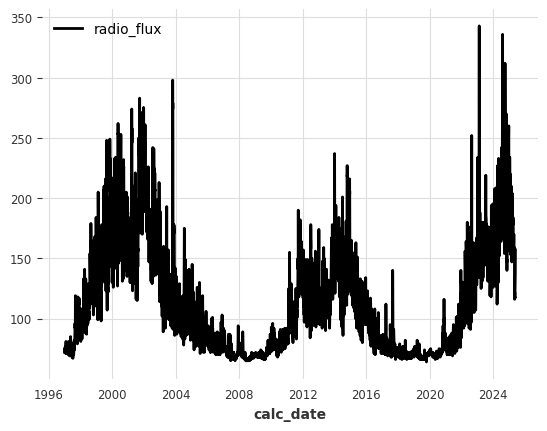

In [6]:
radio_flux = TimeSeries.from_dataframe(radio_flux)
radio_flux.plot();

## Тесты на стационарность ряда radio_flux

In [34]:
# H0 -  ряд является стационарным 
_, p_value, _, _ = tsa.stattools.kpss(radio_flux.values())
print("rejected" if p_value < 0.05 else "not rejected")
print(p_value)

rejected
0.01


/var/folders/j5/2z3wsnhn0w526_3mhsc123hr0000gn/T/ipykernel_15292/2148801472.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  _, p_value, _, _ = tsa.stattools.kpss(radio_flux.values())


In [35]:
# H0 - ряд не является стационарным
_, p_value, _, _, _, _ = tsa.stattools.adfuller(radio_flux.values())
print("rejected" if p_value < 0.05 else "not rejected")
print(p_value)

rejected
0.008110342828198308


/var/folders/j5/2z3wsnhn0w526_3mhsc123hr0000gn/T/ipykernel_15292/108383862.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  radio_flux.plot(ax=ax[0], label=f"KPSS p-value {tsa.stattools.kpss(radio_flux.values())[1]:.2f}");
/var/folders/j5/2z3wsnhn0w526_3mhsc123hr0000gn/T/ipykernel_15292/108383862.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  radio_flux.diff().plot(ax=ax[1], label=f"KPSS p-value {tsa.stattools.kpss(radio_flux.diff().values())[1]:.2f}");


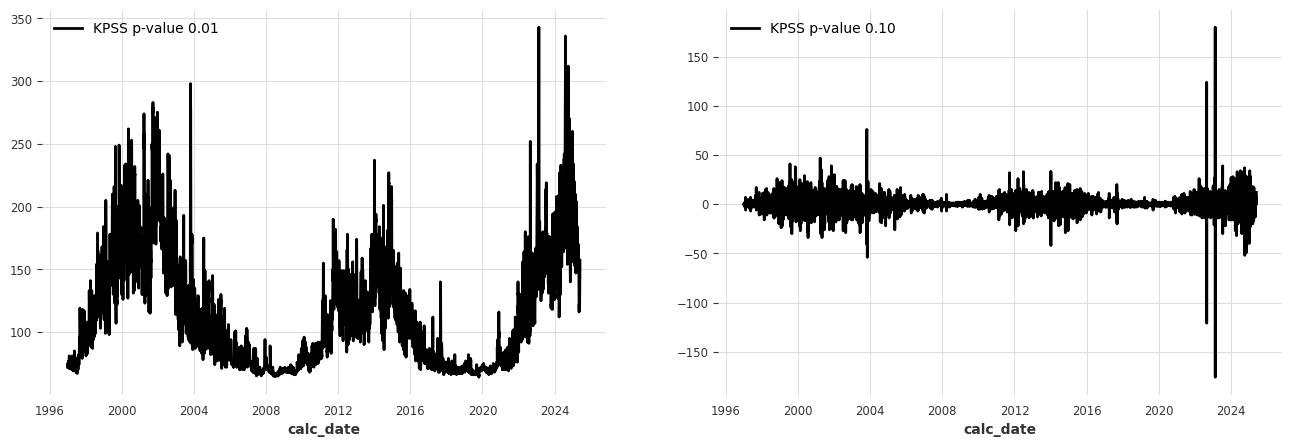

In [36]:
# H0 -  ряд является стационарным 
fig, ax = plt.subplots(1,2,figsize=(16,5))
radio_flux.plot(ax=ax[0], label=f"KPSS p-value {tsa.stattools.kpss(radio_flux.values())[1]:.2f}");
radio_flux.diff().plot(ax=ax[1], label=f"KPSS p-value {tsa.stattools.kpss(radio_flux.diff().values())[1]:.2f}");

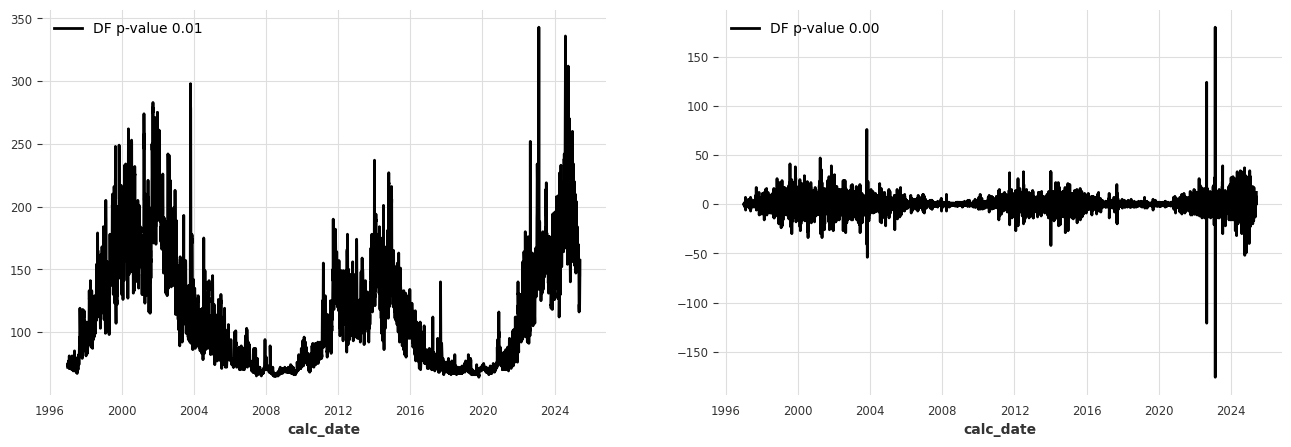

In [38]:
# H0 - ряд не является стационарным
fig, ax = plt.subplots(1,2,figsize=(16,5))
radio_flux.plot(ax=ax[0], label=f"DF p-value {tsa.stattools.adfuller(radio_flux.values())[1]:.2f}");
radio_flux.diff().plot(ax=ax[1], label=f"DF p-value {tsa.stattools.adfuller(radio_flux.diff().values())[1]:.2f}");

## Избавиться от изменения дисперсии

In [39]:
radio_flux_log = radio_flux.map(lambda ts, x: sts.boxcox(x, lmbda=0.1))

<Axes: xlabel='calc_date'>

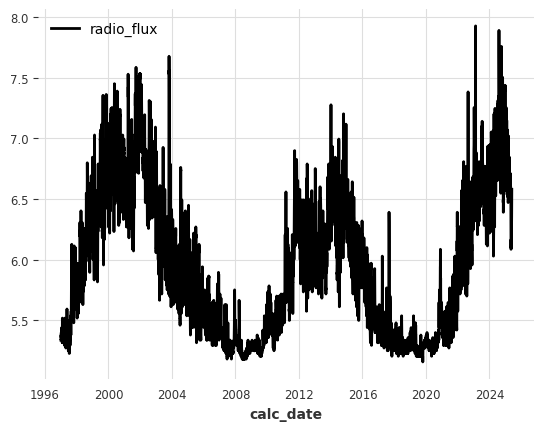

In [40]:
radio_flux_log.plot()

## ACF и PCF для визуального определения параметров модели 

In [41]:
radio_flux_diff = radio_flux.diff()

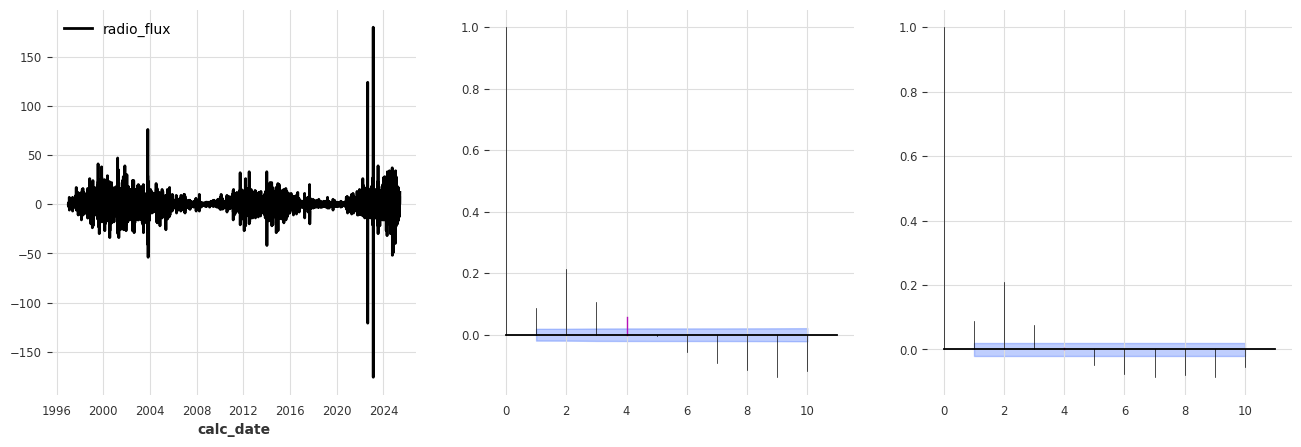

In [42]:
fig, ax = plt.subplots(1,3,figsize=(16,5))
radio_flux_diff.plot(ax=ax[0])
plot_acf(radio_flux_diff, axis=ax[1], max_lag=10, m=4) # q = 4
plot_pacf(radio_flux_diff, axis=ax[2], max_lag=10, method="ywm", m=4) # p = 3
# SARIMA(3, 0, 4)x(0, 1, 0, S=12)
# p d q

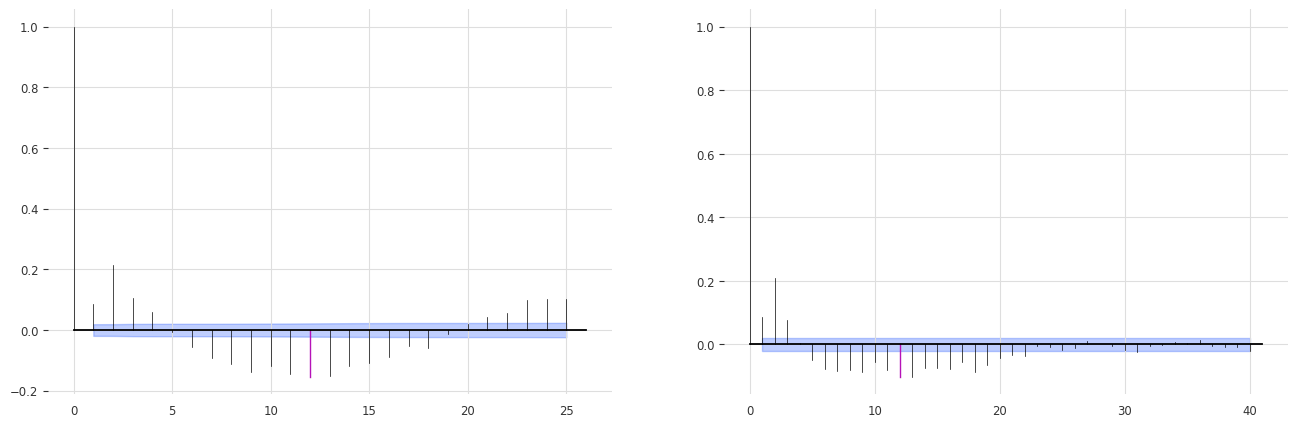

In [46]:
fig, ax = plt.subplots(1,2,figsize=(16,5))
plot_acf(radio_flux_diff, axis=ax[0], max_lag=25, m=12) # q = 4
plot_pacf(radio_flux_diff, axis=ax[1], max_lag=40, method="ywm", m=12) # p = 3
# SARIMA(3, 0, 4)x(0, 1, 0, S=12)
# p d q

In [47]:
radio_flux_diff_12 = radio_flux.diff(12)

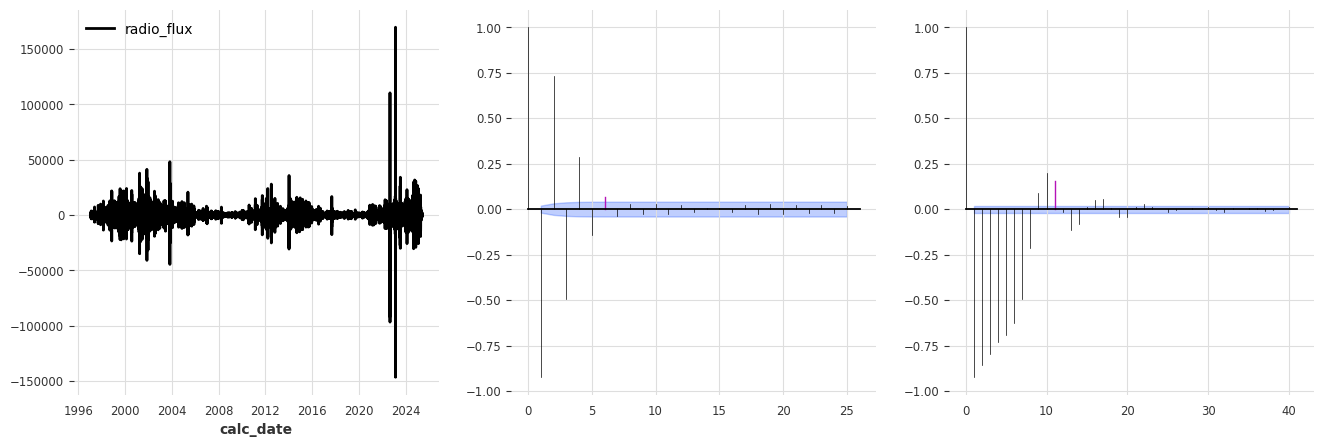

In [52]:
fig, ax = plt.subplots(1,3,figsize=(16,5))
radio_flux_diff_12.plot(ax=ax[0])
plot_acf(radio_flux_diff_12, axis=ax[1], max_lag=25, m=6) # q = 7
plot_pacf(radio_flux_diff_12, axis=ax[2], max_lag=40, method="ywm", m=11) # p = 11

## ARIMA

In [53]:
from darts.models import ARIMA

/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [56]:
model = ARIMA(p=3, d=0, q=3)
model.fit(radio_flux_diff)
fcast = model.historical_forecasts(
    radio_flux_diff, forecast_horizon=1, start_format="position", show_warnings=False
)

/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum 

KeyboardInterrupt: 

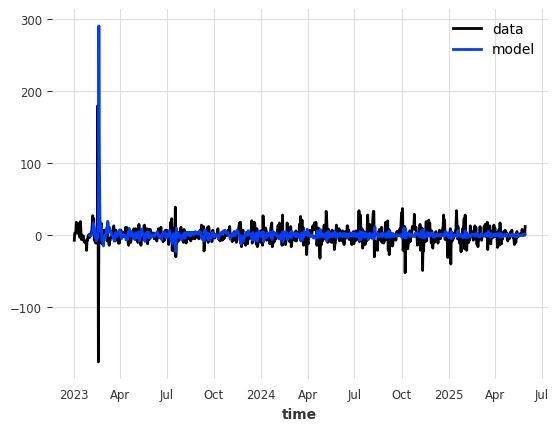

In [49]:
fig, ax = plt.subplots()
radio_flux_diff.plot(ax=ax, label="data")
fcast.plot(ax=ax, label="model")
ax.legend();

## Анализ остатков - необходимые свойства

### 1) несмещенность остатков

### MA(1) - скользящее среднее

In [32]:
model = ARIMA(p=0, d=0, q=1, seasonal_order=(0, 0, 0, 0))
model.fit(radio_flux)
fcast = model.historical_forecasts(
    radio_flux, forecast_horizon=1, start_format="position", show_warnings=False
)

/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


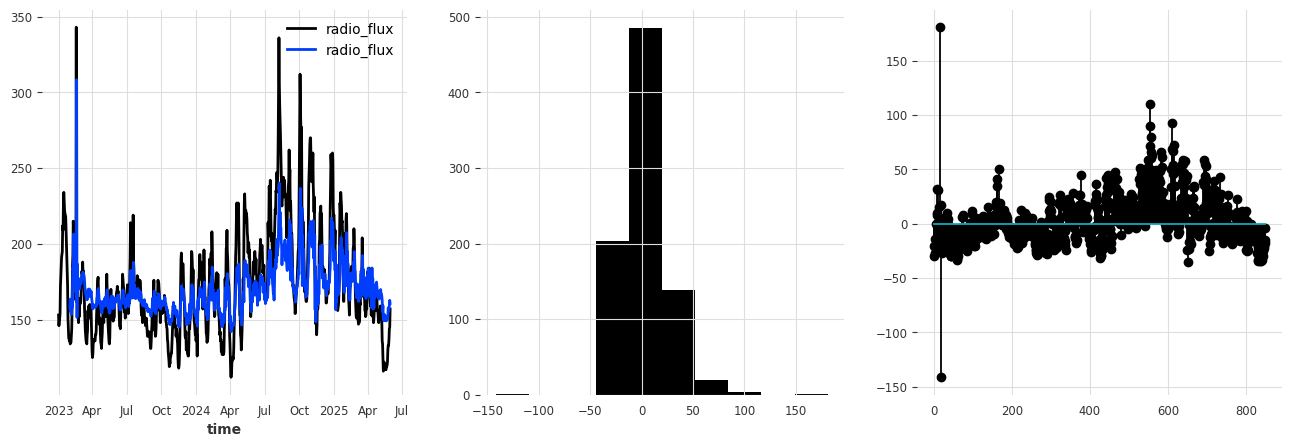

In [33]:
resid = radio_flux[fcast.start_time():] - fcast

fig, ax = plt.subplots(1,3,figsize=(16,5))
radio_flux.plot(ax=ax[0]);
fcast.plot(ax=ax[0]);
ax[1].hist(resid.values());
ax[2].stem(resid.values());

In [34]:
# односторонний т-тест Н0: ср = 0
pvalue = sts.ttest_1samp(resid.values(), 0).pvalue
rejected = pvalue < 0.05
print("zero mean" if not rejected else "non-zero mean")
print(pvalue)

non-zero mean
[1.65647611e-05]


### MA(2)

In [35]:
model = ARIMA(p=0, d=0, q=2, seasonal_order=(0, 0, 0, 0))
model.fit(radio_flux)
fcast = model.historical_forecasts(
    radio_flux, forecast_horizon=1, start_format="position", show_warnings=False
)

/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


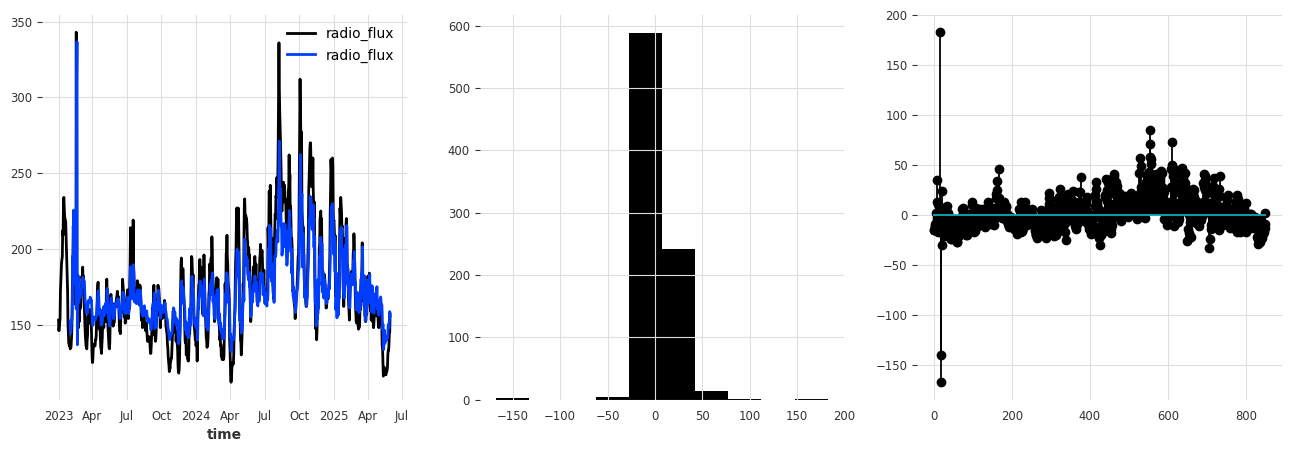

In [36]:
resid = radio_flux[fcast.start_time():] - fcast

fig, ax = plt.subplots(1,3,figsize=(16,5))
radio_flux.plot(ax=ax[0]);
fcast.plot(ax=ax[0]);
ax[1].hist(resid.values());
ax[2].stem(resid.values());

In [37]:
# односторонний т-тест Н0: ср = 0
pvalue = sts.ttest_1samp(resid.values(), 0).pvalue
rejected = pvalue < 0.05
print("zero mean" if not rejected else "non-zero mean")
print(pvalue)

non-zero mean
[0.0010748]


### MA(3)

In [38]:
model = ARIMA(p=0, d=0, q=3, seasonal_order=(0, 0, 0, 0))
model.fit(radio_flux)
fcast = model.historical_forecasts(
    radio_flux, forecast_horizon=1, start_format="position", show_warnings=False
)

/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn(

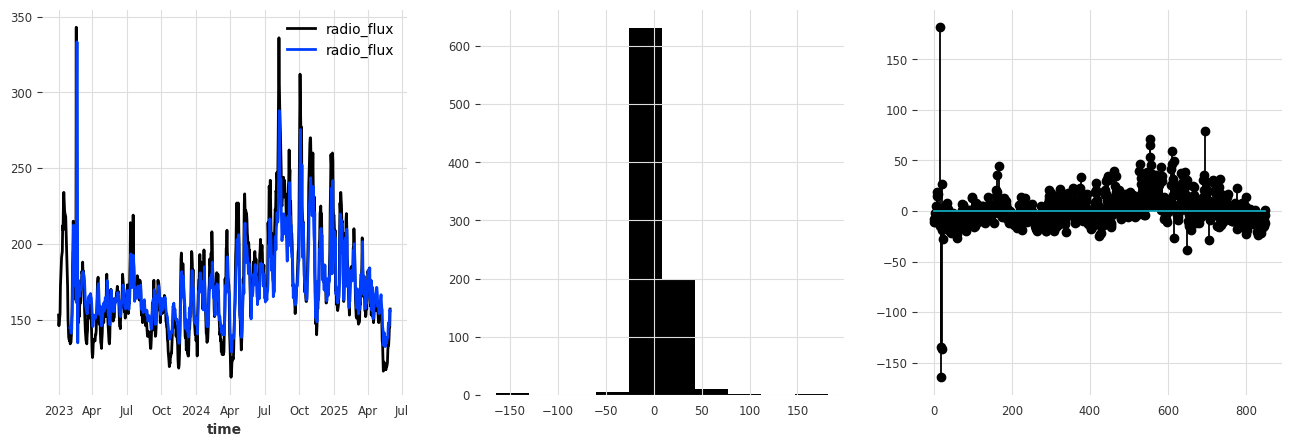

In [39]:
resid = radio_flux[fcast.start_time():] - fcast

fig, ax = plt.subplots(1,3,figsize=(16,5))
radio_flux.plot(ax=ax[0]);
fcast.plot(ax=ax[0]);
ax[1].hist(resid.values());
ax[2].stem(resid.values());

In [40]:
# односторонний т-тест Н0: ср = 0
pvalue = sts.ttest_1samp(resid.values(), 0).pvalue
rejected = pvalue < 0.05
print("zero mean" if not rejected else "non-zero mean")
print(pvalue)

non-zero mean
[0.00942461]


### 2) стационарность остатков

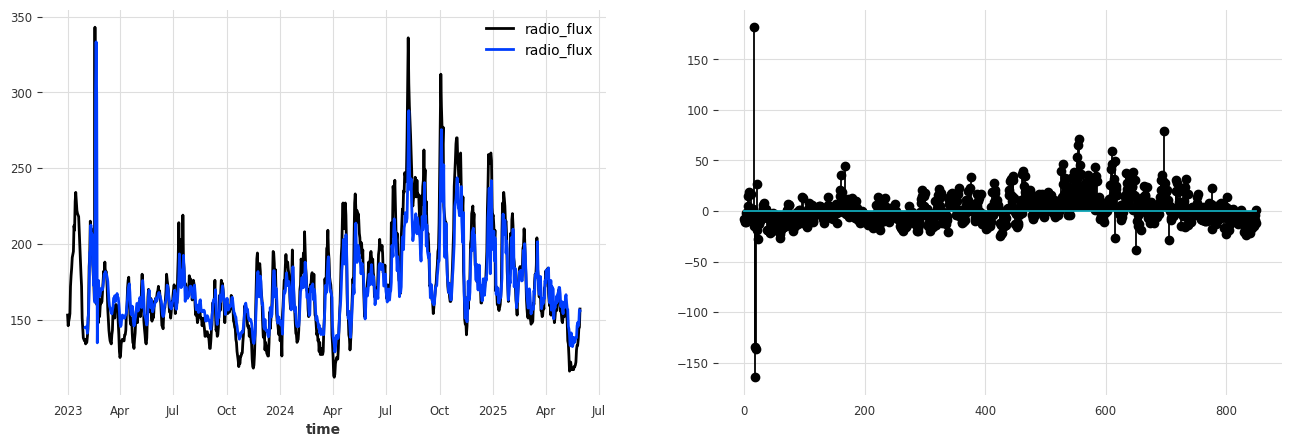

In [43]:
fig, ax = plt.subplots(1,2,figsize=(16,5))
radio_flux.plot(ax=ax[0]);
fcast.plot(ax=ax[0]);
ax[1].stem(resid.values());

In [45]:
pvalue = tsa.stattools.kpss(resid.values())[1]
rejected = pvalue < 0.05
print("stationary" if not rejected else "non-stationary")

non-stationary


/var/folders/j5/2z3wsnhn0w526_3mhsc123hr0000gn/T/ipykernel_18387/2228572355.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  pvalue = tsa.stattools.kpss(resid.values())[1]


### 3) некоррелированность

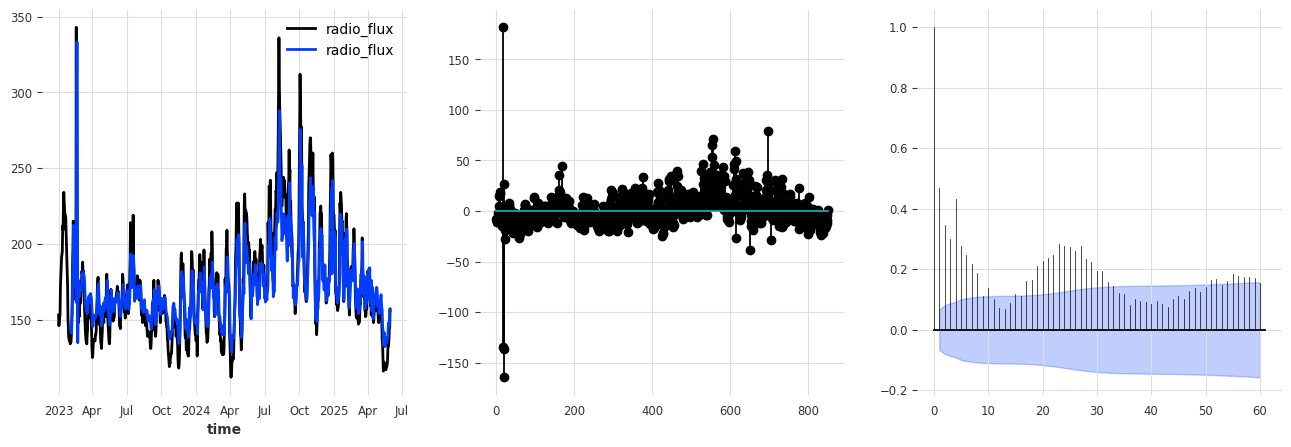

In [48]:
fig, ax = plt.subplots(1,3,figsize=(16,5))
radio_flux.plot(ax=ax[0]);
fcast.plot(ax=ax[0]);
ax[1].stem(resid.values());
plot_acf(resid, max_lag=12*5, axis=ax[2])

In [49]:
pvalue = sts.ttest_1samp(resid.values(), 0).pvalue
rejected = pvalue < 0.05
print("zero mean" if not rejected else "non-zero mean")
print(pvalue)

non-zero mean
[0.00942461]


In [50]:
# проверка на корреляцию остатков
sm.stats.acorr_ljungbox(resid.values(), model_df=1)["lb_pvalue"].max()
rejected = pvalue < 0.05
print("there is", "no autocorrelation" if not rejected else "autocorrelation")

there is autocorrelation


## Желательные свойства остатков

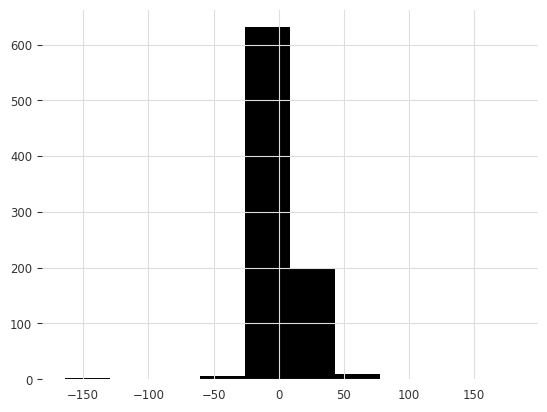

In [51]:
plt.hist(resid.values());

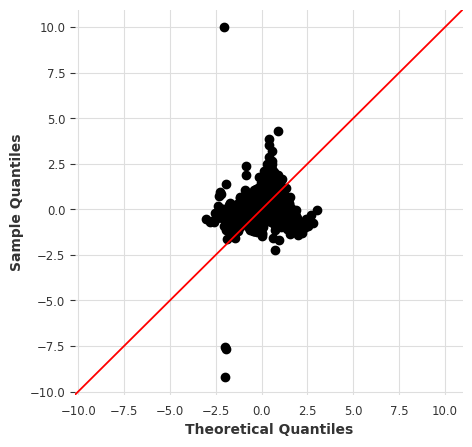

In [54]:
fig, ax = plt.subplots(figsize=(5,5))
sm.qqplot(resid.values(), ax=ax, fit=True, line="45");

In [56]:
pvalue = sts.shapiro(resid.values()).pvalue
rejected = pvalue < 0.05
print("normal" if not rejected else "not normal")
print(pvalue)

not normal
2.0050310338221292e-31


## Бейзлайны

In [57]:
from darts.models import NaiveMean, NaiveSeasonal, NaiveDrift, NaiveMovingAverage

<Axes: xlabel='calc_date'>

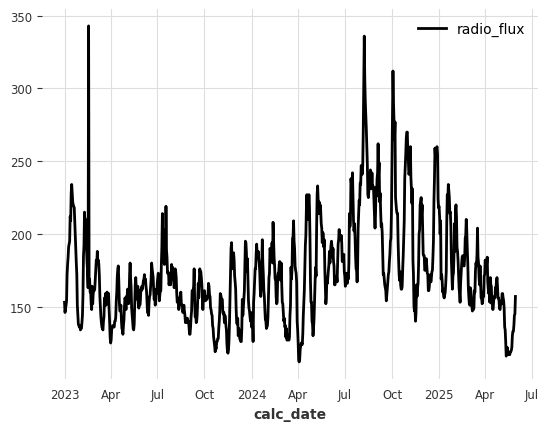

In [65]:
radio_flux.plot()

In [18]:
train, val = radio_flux.split_before(pd.Timestamp("2025-01-01"))

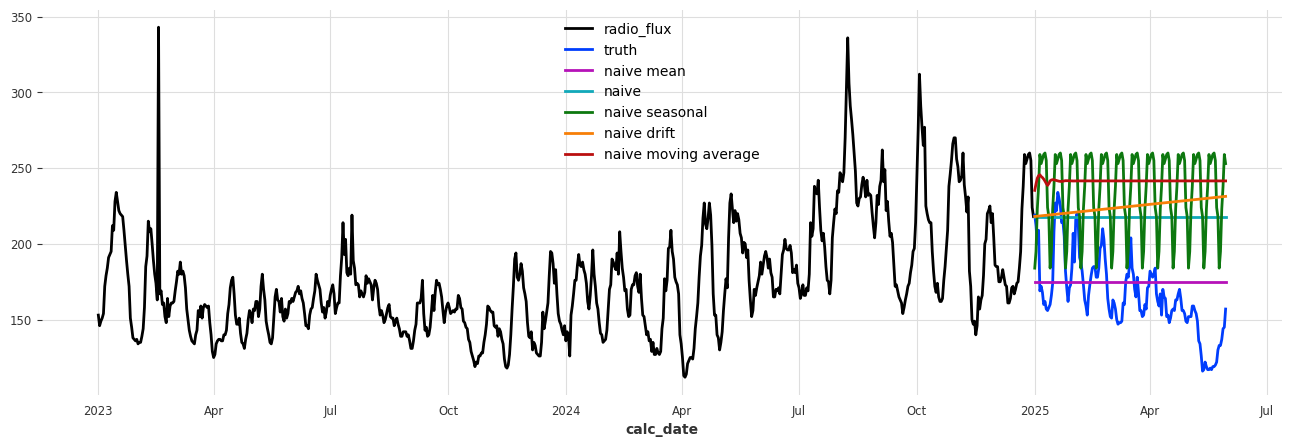

In [64]:
naive_mean_fcast = NaiveMean().fit(train).predict(len(val))
naive_fcast = NaiveSeasonal(K=1).fit(train).predict(len(val))
naive_seasonal_fcast = NaiveSeasonal(K=12).fit(train).predict(len(val))
naive_drift_fcast = NaiveDrift().fit(train).predict(len(val))
naive_ma_fcast = NaiveMovingAverage(12).fit(train).predict(len(val))

fig, ax = plt.subplots(figsize=(16,5))
train.plot(ax=ax);
val.plot(label="truth", ax=ax);
naive_mean_fcast.plot(label="naive mean", ax=ax);
naive_fcast.plot(label="naive", ax=ax);
naive_seasonal_fcast.plot(label="naive seasonal", ax=ax);
naive_drift_fcast.plot(label="naive drift", ax=ax);
naive_ma_fcast.plot(label="naive moving average", ax=ax);

In [66]:
from darts.models import ExponentialSmoothing
from darts.utils.utils import ModelMode

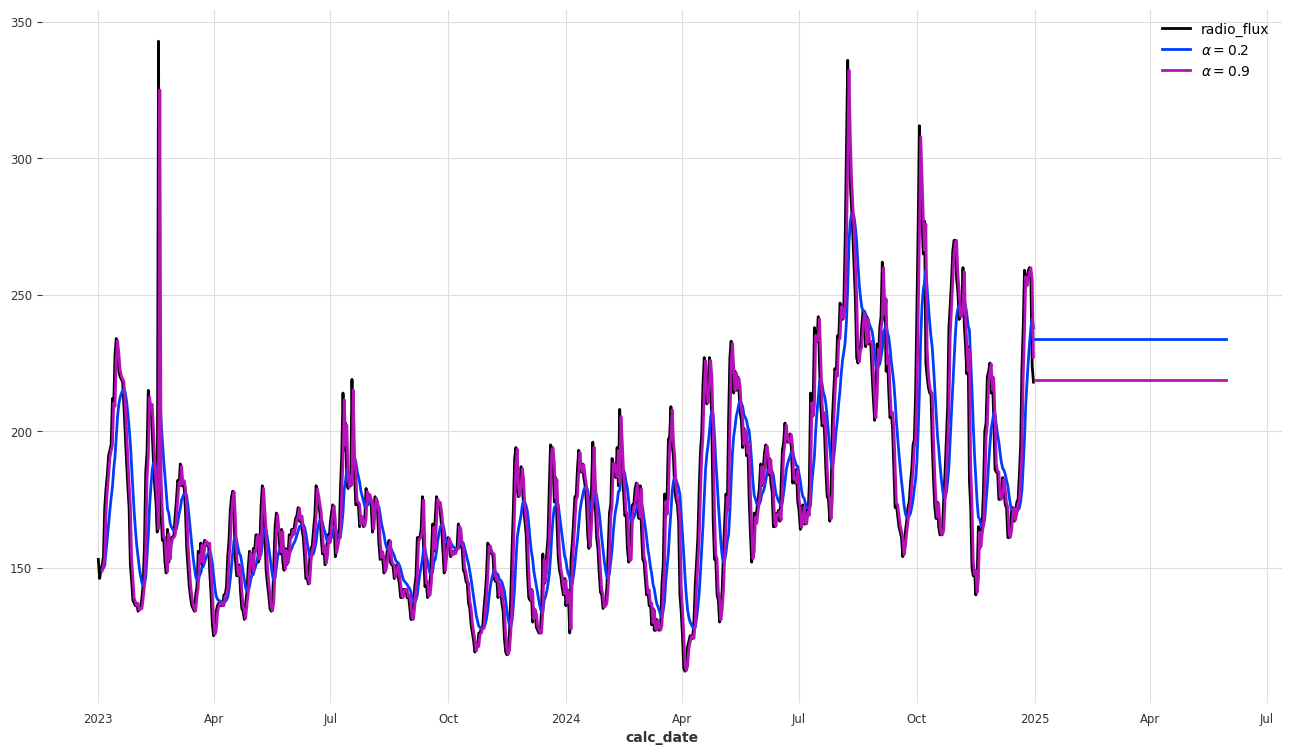

In [67]:
ses_02_bcast = ExponentialSmoothing(trend=ModelMode.NONE, seasonal=ModelMode.NONE, smoothing_level=0.2).historical_forecasts(train)
ses_09_bcast = ExponentialSmoothing(trend=ModelMode.NONE, seasonal=ModelMode.NONE, smoothing_level=0.9).historical_forecasts(train)

ses_02_fcast = ExponentialSmoothing(trend=ModelMode.NONE, seasonal=ModelMode.NONE, smoothing_level=0.2).fit(train).predict(len(val))
ses_09_fcast = ExponentialSmoothing(trend=ModelMode.NONE, seasonal=ModelMode.NONE, smoothing_level=0.9).fit(train).predict(len(val))

fig, ax = plt.subplots(figsize=(16,9))
train.plot(ax=ax);
ses_02_bcast.plot(label="$\\alpha = 0.2$", color="C1", ax=ax);
ses_09_bcast.plot(label="$\\alpha = 0.9$", color="C2", ax=ax);
ses_02_fcast.plot(label=None, color="C1", ax=ax);
ses_09_fcast.plot(label=None, color="C2", ax=ax);

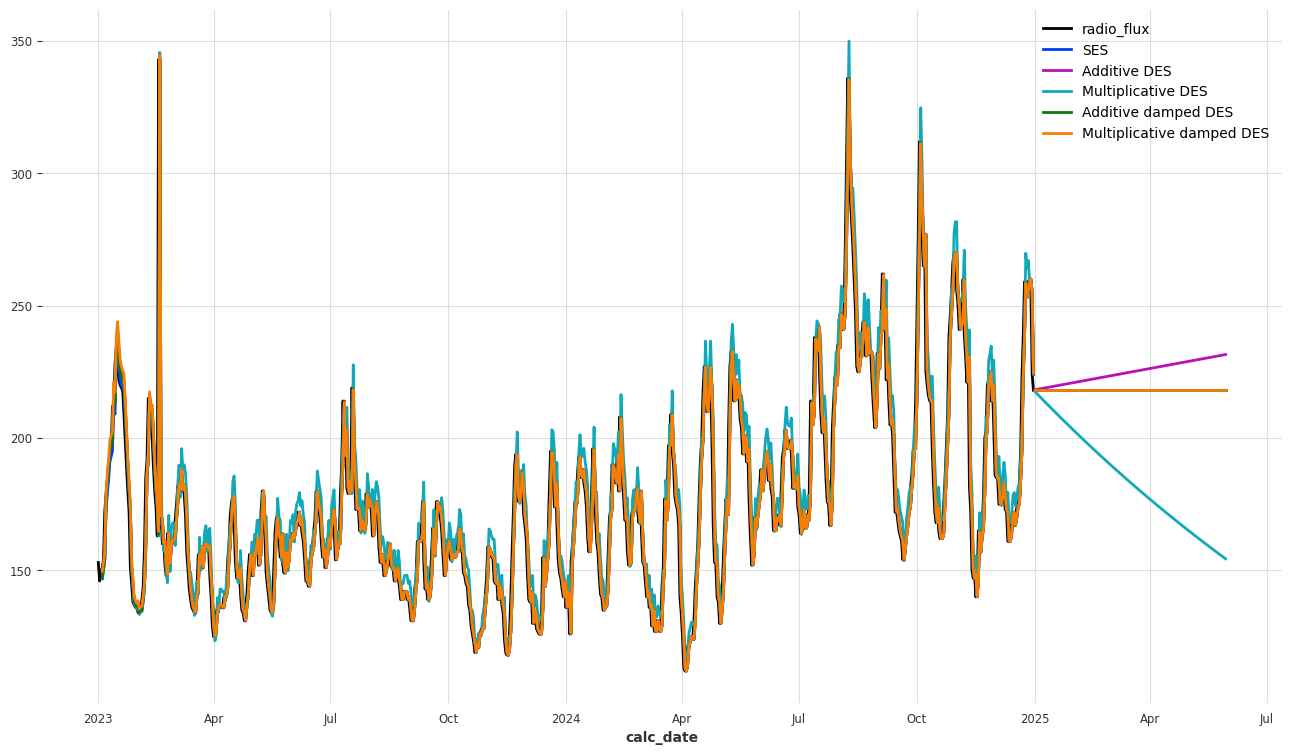

In [68]:
ses = ExponentialSmoothing(trend=ModelMode.NONE, seasonal=ModelMode.NONE, smoothing_level=1)
bes = ExponentialSmoothing(trend=ModelMode.ADDITIVE, seasonal=ModelMode.NONE, smoothing_level=0.98, smoothing_trend=0)
mbes = ExponentialSmoothing(trend=ModelMode.MULTIPLICATIVE, seasonal=ModelMode.NONE, smoothing_level=0.98, smoothing_trend=0)
dbes = ExponentialSmoothing(trend=ModelMode.ADDITIVE, seasonal=ModelMode.NONE, damped=True, smoothing_level=0.99, smoothing_trend=0, damping_trend=0.98)
dmbes = ExponentialSmoothing(trend=ModelMode.MULTIPLICATIVE, seasonal=ModelMode.NONE, damped=True, smoothing_level=0.98, smoothing_trend=0, damping_trend=0.98)

ses_bcast = ses.historical_forecasts(train)
bes_bcast = bes.historical_forecasts(train)
mbes_bcast = mbes.historical_forecasts(train)
dbes_bcast = dbes.historical_forecasts(train)
dmbes_bcast = dmbes.historical_forecasts(train)

ses_fcast = ses.fit(train).predict(len(val))
bes_fcast = bes.fit(train).predict(len(val))
mbes_fcast = mbes.fit(train).predict(len(val))
dbes_fcast = dbes.fit(train).predict(len(val))
dmbes_fcast = dmbes.fit(train).predict(len(val))

fig, ax = plt.subplots(figsize=(16,9))
train.plot(ax=ax);
ses_bcast.plot(label="SES", color="C1", ax=ax);
bes_bcast.plot(label="Additive DES", color="C2", ax=ax);
mbes_bcast.plot(label="Multiplicative DES", color="C3", ax=ax);
dbes_bcast.plot(label="Additive damped DES", color="C4", ax=ax);
dmbes_bcast.plot(label="Multiplicative damped DES", color="C5", ax=ax);
ses_fcast.plot(label=None, color="C1", ax=ax);
bes_fcast.plot(label=None, color="C2", ax=ax);
mbes_fcast.plot(label=None, color="C3", ax=ax);
dbes_fcast.plot(label=None, color="C4", ax=ax);
dmbes_fcast.plot(label=None, color="C5", ax=ax);

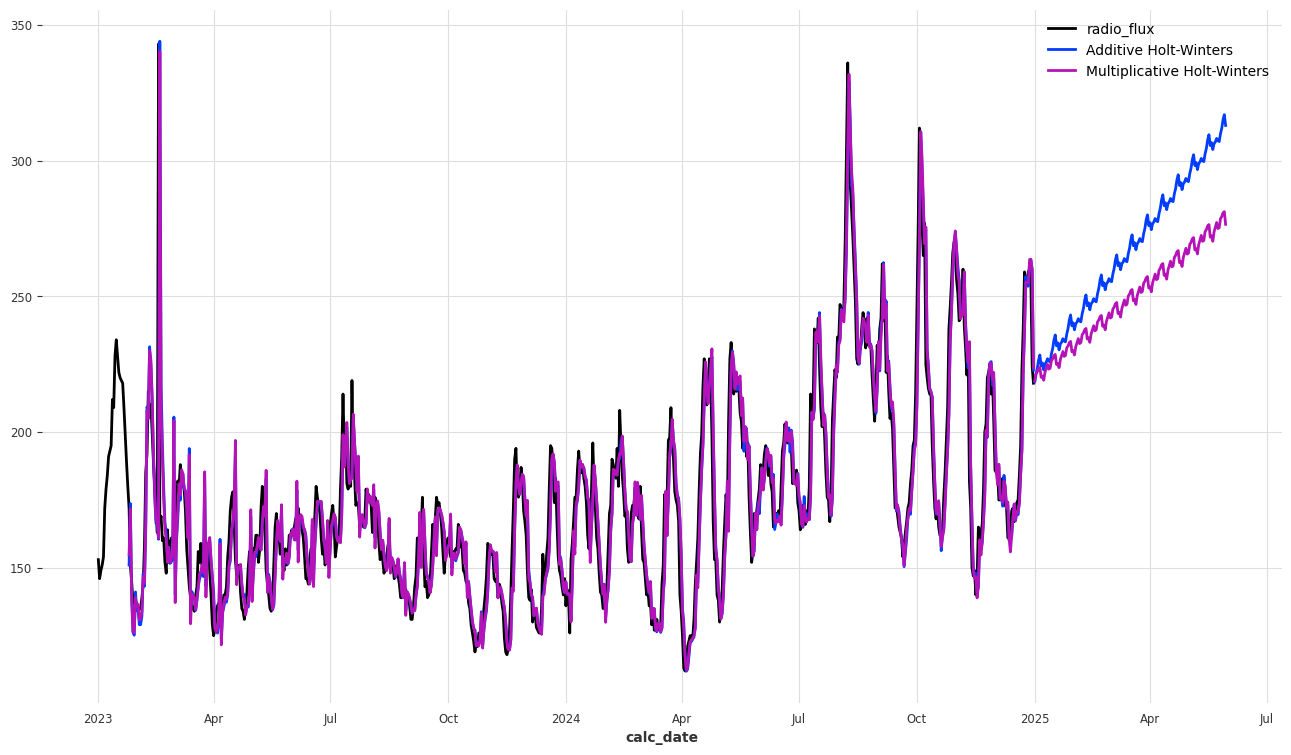

In [69]:
ets_additive = ExponentialSmoothing(trend=ModelMode.ADDITIVE, seasonal=ModelMode.ADDITIVE, seasonal_periods=12)
ets_mult = ExponentialSmoothing(trend=ModelMode.ADDITIVE, seasonal=ModelMode.MULTIPLICATIVE, seasonal_periods=12)

ets_additive_bcast = ets_additive.historical_forecasts(train)
ets_mult_bcast = ets_mult.historical_forecasts(train)

ets_additive_fcast = ets_additive.fit(train).predict(len(val))
ets_mult_fcast = ets_mult.fit(train).predict(len(val))

fig, ax = plt.subplots(figsize=(16,9))
train.plot(ax=ax);
ets_additive_bcast.plot(label="Additive Holt-Winters", color="C1", ax=ax);
ets_mult_bcast.plot(label="Multiplicative Holt-Winters", color="C2", ax=ax);
ets_additive_fcast.plot(label=None, color="C1", ax=ax);
ets_mult_fcast.plot(label=None, color="C2", ax=ax);

## Вероятностные предсказания

In [70]:
from darts.models import ExponentialSmoothing
from darts.utils.utils import ModelMode

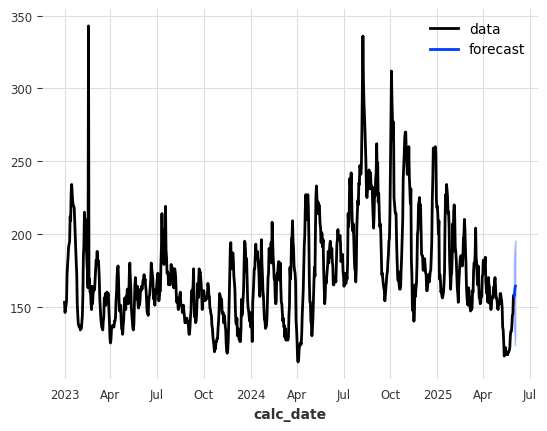

In [73]:
ets = ExponentialSmoothing()
ets.fit(radio_flux)
fcast = ets.predict(4, num_samples=50)
fig, ax = plt.subplots()
radio_flux.plot(ax=ax, label="data")
fcast.plot(ax=ax, label="forecast");

In [75]:
from darts.models import AutoARIMA #StatsForecastAutoARIMA as AutoARIMA

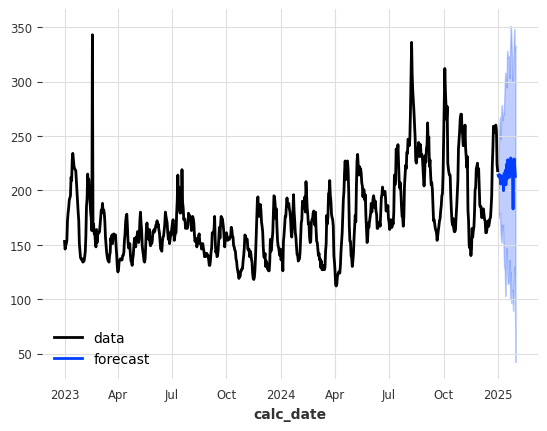

In [77]:
arima = AutoARIMA()
arima.fit(train)
fcast = arima.predict(30, num_samples=50)
fig, ax = plt.subplots()
train.plot(ax=ax, label="data")
fcast.plot(ax=ax, label="forecast");

In [125]:
from darts.models import ARIMA

/opt/homebrew/Cellar/jupyterlab/4.4.2_1/libexec/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [127]:
model = ARIMA(p=1, d=0, q=1, seasonal_order=(0, 1, 1, 4))
model.fit(radio_flux)

ARIMA(p=1, d=0, q=1, seasonal_order=(0, 1, 1, 4), trend=None, random_state=None, add_encoders=None)

In [ ]:
fcast = model.historical_forecasts(
    radio_flux, forecast_horizon=1, start_format="position", show_warnings=False
)

In [ ]:
fig, ax = plt.subplots()
radio_flux.plot(ax=ax, label="data")
fcast.plot(ax=ax, label="model")
ax.legend();

In [33]:
train, test = radio_flux.split_before(pd.Timestamp("2025-04-01"))

In [34]:
from darts.models import AutoARIMA, AutoETS 

In [37]:
arima = AutoARIMA()
ets = AutoETS(season_length=12, model="ZZA")
arima_fcast = arima.fit(train).predict(len(test), num_samples=50)
ets_fcast = ets.fit(train).predict(len(test), num_samples=50)

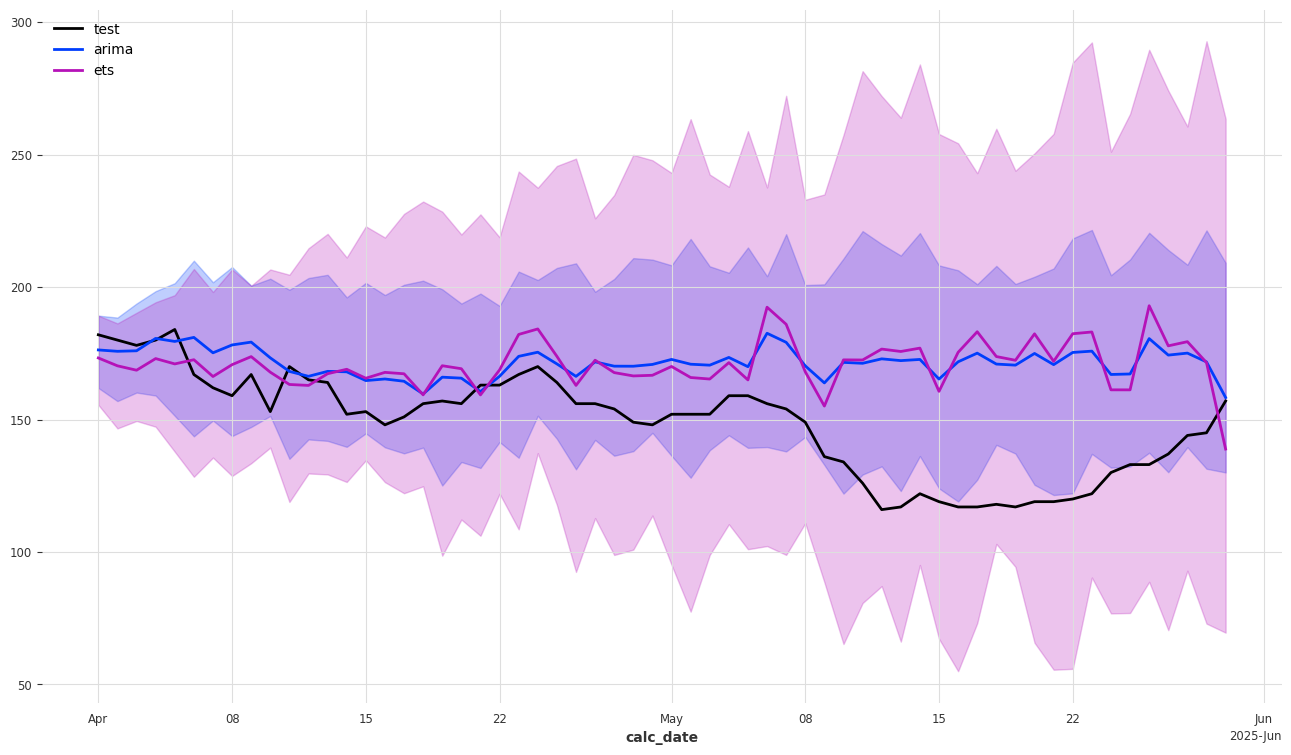

In [38]:
fig, ax = plt.subplots(figsize=(16,9))
# train.plot(label="train", ax=ax);
test.plot(label="test", ax=ax);
arima_fcast.plot(label="arima", ax=ax);
ets_fcast.plot(label="ets", ax=ax);

In [39]:
mse([test, test], [arima_fcast, ets_fcast])

[np.float64(905.9813884668562), np.float64(1023.2390586710615)]

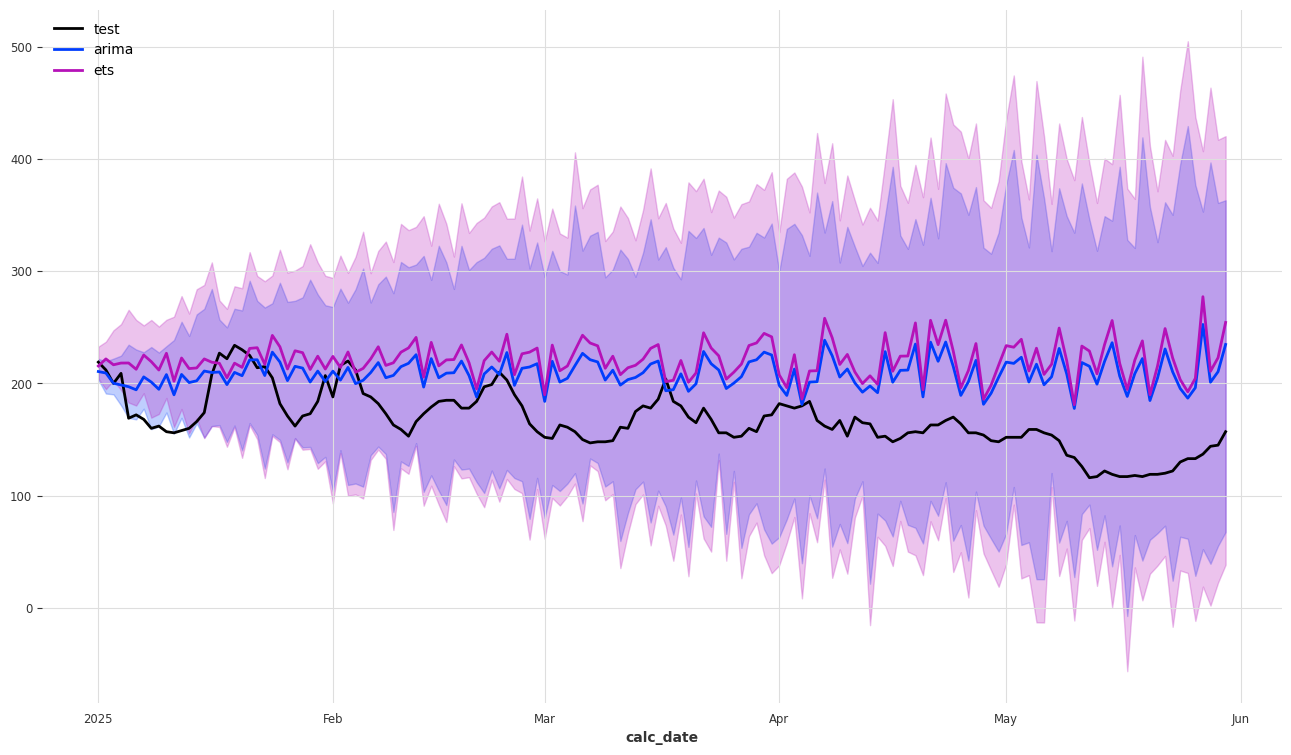

In [30]:
fig, ax = plt.subplots(figsize=(16,9))
# train.plot(label="train", ax=ax);
test.plot(label="test", ax=ax);
arima_fcast.plot(label="arima", ax=ax);
ets_fcast.plot(label="ets", ax=ax);

In [31]:
from darts.metrics.metrics import mse

In [32]:
mse([test, test], [arima_fcast, ets_fcast])

[np.float64(2640.5713544738783), np.float64(3939.4168929688244)]

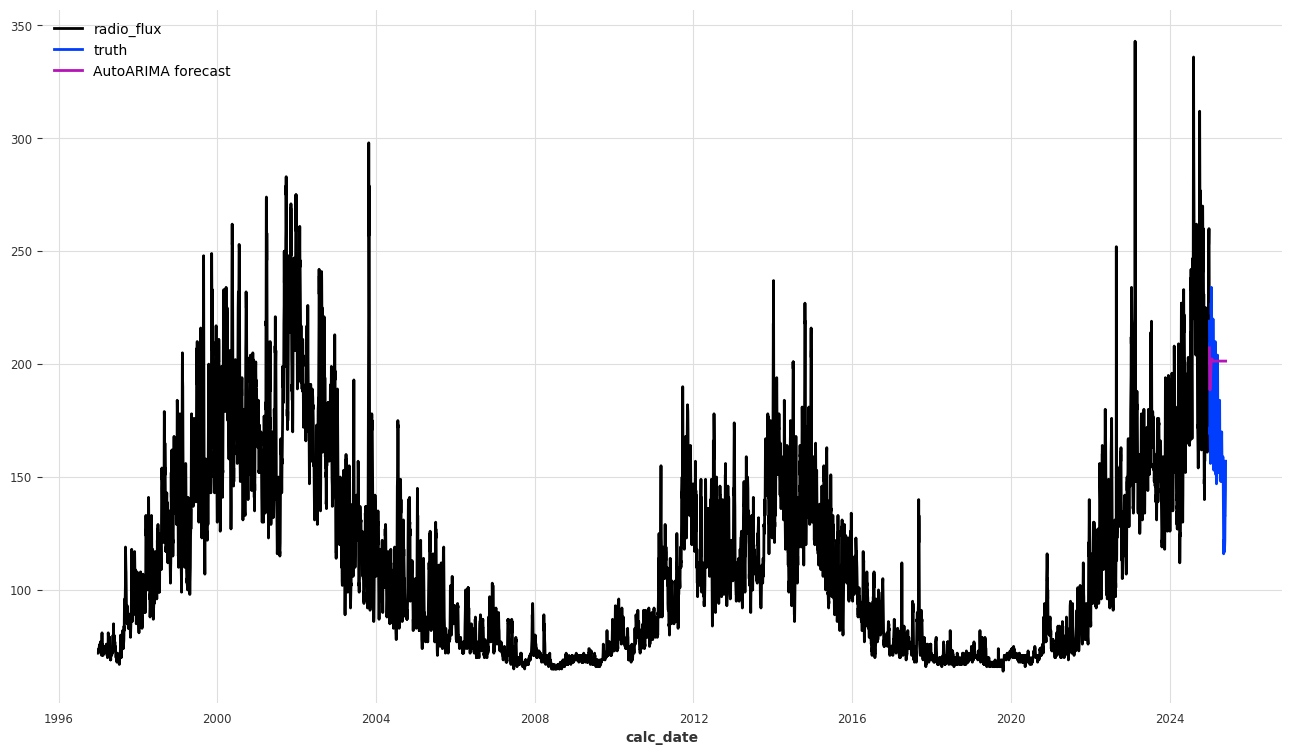

In [22]:
fig, ax = plt.subplots(figsize=(16,9))
train.plot(ax=ax);
val.plot(label="truth", ax=ax);
auto_fcast.plot(label="AutoARIMA forecast", ax=ax);